# Part 3: Model Identification and Implementation

**Dataset:** mahjong discard-decision logs (100,000-row slice), engineered into a
337-dim feature vector per decision (hand contents, tile-efficiency/shanten features,
drawn-tile identity, per-seat opponent context) via `mahjong_features.py` and `mahjong_shanten.py`. Shanten and drawn-tile identity are added features extrapolated from dataset. Features vector quickly exploded in size once you factor in 4=players, melds, and seat positioning. Each seat's 5 raw columns become: points (1) + discard count (1) + tsumogiri ratio (1) + riichi flag (1) + meld-type histogram (34) + meld count (1) = 39 — then this whole block is computed four times, once per seat, rotated into a self/next/across/previous frame(+156). Adding Shanten(+35) and draw-tile identity(+34) also didn't help.

**Three models, two business objectives:**

| # | Model | Type | Business objective |
|---|---|---|---|
| 1 | Logistic Regression | Supervised | Predict which of the 34 tile types a player will discard |
| 2 | Random Forest | Supervised | Same objective as Model 1, different model family for comparison |
| 3 | K-Means clustering | Unsupervised | **Different objective:** segment decision-points into natural strategic archetypes (e.g. defensive/attacking/near-tenpai hands), for use in player coaching/analytics dashboards rather than exact discard prediction |


## Setup

Import dependencies and dataset. I need to cache dataset of this size. mahjong_features.py and mahjong_shanten.py contains helper functions to build out features from raw dataset. Remove last round incase of incomplete round. Total dimensions should be 337
Data is organized into these arrays:

X: Flat features

y: What tile was discarded (0-33)

mask: Legal-discard mask. Keeps track of legal moves to restrict predictions

rounds: Track rounds, needed for GRU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import sys

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              silhouette_score)

np.random.seed(42)

# read data slice
CSV_PATH = "mahjong_ml_slice_100000.csv"   # CSV path
CACHE_DIR = "cache_100k"                    # local folder used to save/reload built features

# make mahjong_features.py and mahjong_shanten.py importable
# (must be in the same folder as this notebook, or update this path)
sys.path.insert(0, os.path.dirname(os.path.abspath(CSV_PATH)) or ".")

TILE_LABELS = [f"M{i}" for i in range(1, 10)] + [f"P{i}" for i in range(1, 10)] + \
              [f"S{i}" for i in range(1, 10)] + ["E", "S", "W", "N", "Haku", "Hatsu", "Chun"]
def tile_family(t):
    if t <= 8: return "Manzu"
    if t <= 17: return "Pinzu"
    if t <= 26: return "Souzu"
    return "Honors"
FAMILY_COLORS = {"Manzu": "#D85A30", "Pinzu": "#5DCAA5", "Souzu": "#7F77DD", "Honors": "#B4B2A9"}

# load cached features if present, else build them from the CSV and cache them
os.makedirs(CACHE_DIR, exist_ok=True)
cache_file = os.path.join(CACHE_DIR, "X.npy")

if os.path.exists(cache_file):
    print("Loading cached features from", CACHE_DIR)
    X = np.load(os.path.join(CACHE_DIR, "X.npy"))
    y = np.load(os.path.join(CACHE_DIR, "y.npy"))
    masks = np.load(os.path.join(CACHE_DIR, "masks.npy"))
    rounds = np.load(os.path.join(CACHE_DIR, "rounds.npy"))
else:
    print(f"No cache found -- building features from {CSV_PATH} , this can take several minutes...")
    from mahjong_features import build_dataset
    t0 = time.time()
    X, y, masks, seqs, tg_seqs, seq_lens, rounds = build_dataset(CSV_PATH)
    print(f"built in {time.time()-t0:.1f}s")
    np.save(os.path.join(CACHE_DIR, "X.npy"), X)
    np.save(os.path.join(CACHE_DIR, "y.npy"), y)
    np.save(os.path.join(CACHE_DIR, "masks.npy"), masks)
    np.save(os.path.join(CACHE_DIR, "rounds.npy"), rounds)
    print("cached for next time in", CACHE_DIR)

print(f"X: {X.shape}, y: {y.shape}, {len(np.unique(rounds))} complete rounds")

No cache found -- building features from mahjong_ml_slice_100000.csv (this can take several minutes)...
Dropped 6 row(s) from the final, truncated round (6790 complete rounds remain).
Built dataset: 99994 rows kept, 0 rows skipped (non-discard actions), feature dim = 337, 6790 rounds
built in 829.3s
cached for next time in cache_100k
X: (99994, 337), y: (99994,), 6790 complete rounds


## Data loading and train / validation / test split

Split data for train/val/test.  The split is done **by round, not by row** -- several rows
come from the same hand, so a row-level random split would leak near-duplicate context
across splits.

In [11]:
X = np.load(os.path.join(CACHE_DIR, "X.npy"))
y = np.load(os.path.join(CACHE_DIR, "y.npy"))
masks = np.load(os.path.join(CACHE_DIR, "masks.npy"))
rounds = np.load(os.path.join(CACHE_DIR, "rounds.npy"))
print(f"X: {X.shape}, y: {y.shape}, {len(np.unique(rounds))} complete rounds")

def three_way_round_split(rounds, val_frac=0.15, test_frac=0.15, seed=42):
    unique_rounds = np.unique(rounds)
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(unique_rounds)
    n = len(shuffled)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    test_rounds = set(shuffled[:n_test])
    val_rounds = set(shuffled[n_test:n_test + n_val])
    train_rounds = set(shuffled[n_test + n_val:])
    test_mask = np.isin(rounds, list(test_rounds))
    val_mask = np.isin(rounds, list(val_rounds))
    train_mask = np.isin(rounds, list(train_rounds))
    return train_mask, val_mask, test_mask

split_path = os.path.join(CACHE_DIR, "train_mask.npy")
if os.path.exists(split_path):
    train_mask = np.load(os.path.join(CACHE_DIR, "train_mask.npy"))
    val_mask = np.load(os.path.join(CACHE_DIR, "val_mask.npy"))
    test_mask = np.load(os.path.join(CACHE_DIR, "test_mask.npy"))
else:
    train_mask, val_mask, test_mask = three_way_round_split(rounds)
    np.save(split_path, train_mask)
    np.save(os.path.join(CACHE_DIR, "val_mask.npy"), val_mask)
    np.save(os.path.join(CACHE_DIR, "test_mask.npy"), test_mask)

print(f"train: {train_mask.sum()} rows ({len(np.unique(rounds[train_mask]))} rounds)")
print(f"val:   {val_mask.sum()} rows ({len(np.unique(rounds[val_mask]))} rounds)")
print(f"test:  {test_mask.sum()} rows ({len(np.unique(rounds[test_mask]))} rounds)") #part4

Xtr, ytr, mtr = X[train_mask], y[train_mask], masks[train_mask]
Xv, yv, mv = X[val_mask], y[val_mask], masks[val_mask]
Xte, yte, mte = X[test_mask], y[test_mask], masks[test_mask]

# random-among-legal / majority-class baselines on the validation split, for context
vals_, counts_ = np.unique(ytr, return_counts=True)
majority_class = vals_[np.argmax(counts_)]
maj_correct, rand_frac = 0, 0.0
for i in range(len(yv)):
    legal = np.where(mv[i] == 1)[0]
    if majority_class in legal:
        maj_correct += (yv[i] == majority_class)
    rand_frac += 1.0 / len(legal) if yv[i] in legal else 0.0
print(f"\nRandom-among-legal baseline: {rand_frac/len(yv):.2%}")
print(f"Majority-class baseline:     {maj_correct/len(yv):.2%}")

X: (99994, 337), y: (99994,), 6790 complete rounds
train: 70066 rows (4754 rounds)
val:   14550 rows (1018 rounds)
test:  15378 rows (1018 rounds)

Random-among-legal baseline: 18.05%
Majority-class baseline:     4.72%


## Dimensionality reduction: PCA on the full feature set

PCA on the standardized 337-dim feature vector.
This serves two purposes used throughout the rest of the notebook: (1) supporting data
on how much of the feature space's variance is captured by fewer dimensions, useful
context for judging whether a lower-dimensional representation would suffice for each
model, and (2) the actual reduced-dimensional input used by the K-Means model, since
distance-based clustering degrades in high-dimensional raw feature space.

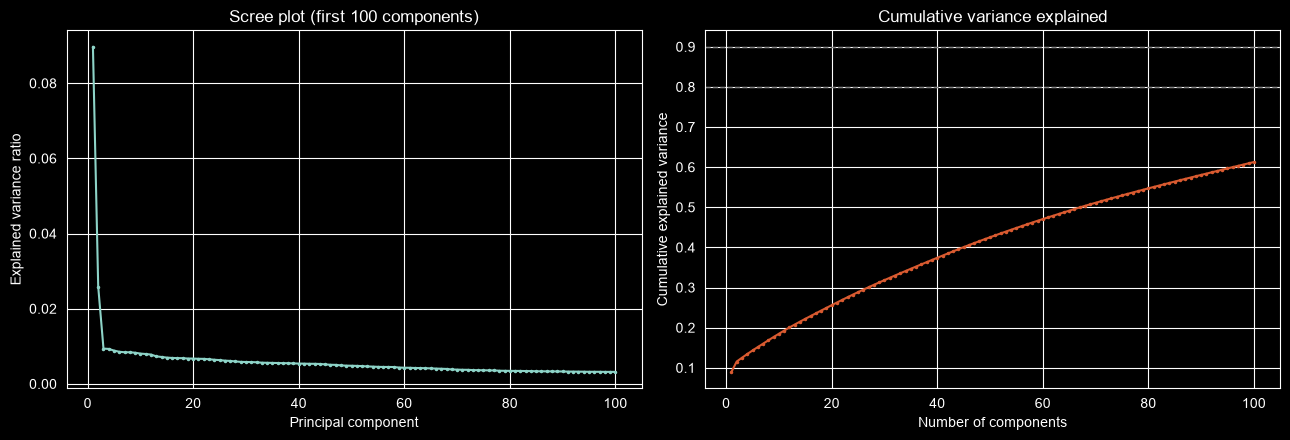

Components needed for 80% variance: > 100 (not reached) (out of 337)
  since several 34-dim one-hot-style blocks each contribute roughly equal small variance)
Components needed for 90% variance: > 100 (not reached)
Variance explained by 2 components (for visualization below): 11.6%


In [13]:
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xv_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xv), scaler.transform(Xte)

pca_full = PCA(n_components=100, random_state=42).fit(Xtr_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(1, 101), pca_full.explained_variance_ratio_[:100], marker='.', ms=3)
axes[0].set_xlabel("Principal component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (first 100 components)")

axes[1].plot(range(1, 101), cum_var, marker='.', ms=3, color="#D85A30")
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(0.90, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance explained")
plt.tight_layout(); plt.show()

def components_for_variance(cum_var, threshold):
    reached = np.where(cum_var >= threshold)[0]
    if len(reached) == 0:
        return None  # threshold not reached within the fitted number of components
    return reached[0] + 1

n_80 = components_for_variance(cum_var, 0.80)
n_90 = components_for_variance(cum_var, 0.90)
n_80_str = str(n_80) if n_80 is not None else f"> {len(cum_var)} (not reached)"
n_90_str = str(n_90) if n_90 is not None else f"> {len(cum_var)} (not reached)"
print(f"Components needed for 80% variance: {n_80_str} (out of 337)")
print("  since several 34-dim one-hot-style blocks each contribute roughly equal small variance)")
print(f"Components needed for 90% variance: {n_90_str}")
print(f"Variance explained by 2 components (for visualization below): {cum_var[1]:.1%}")

# For the per-model PCA comparisons below, we use a fixed (50 components  ~6.7x reduction)
# rather than the 80%-variance threshold, since that threshold needs 166 of 337 dims here and
# wouldn't meaningfully test "reduced-dimensionality" fit.
N_COMPONENTS_COMPARISON = 50

Using only 100 out of 337 does not account for 80% of the variance. This feature set does not compress tightly.

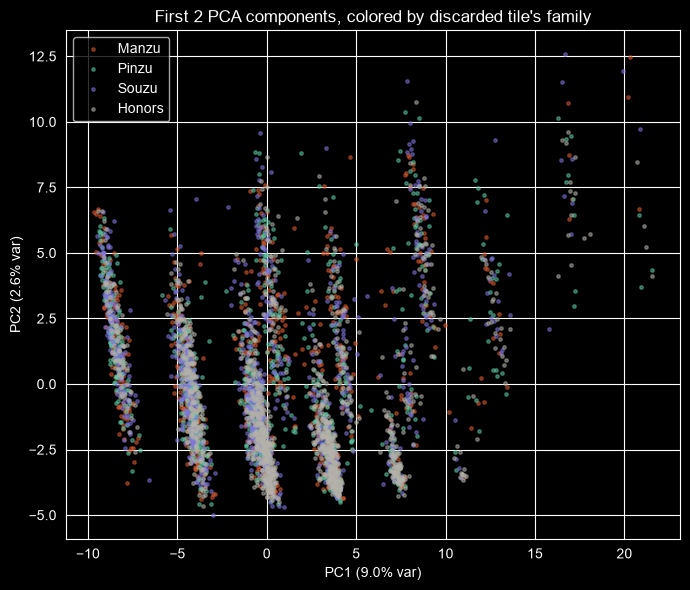

In [5]:
# 2D PCA visualization, colored by tile family of the discarded label (subsampled for plotting speed)
pca_2d = PCA(n_components=2, random_state=42).fit(Xtr_s)
sample_idx = np.random.RandomState(0).choice(len(Xtr_s), 4000, replace=False)
Xtr_2d = pca_2d.transform(Xtr_s[sample_idx])
families = np.array([tile_family(t) for t in ytr[sample_idx]])

fig, ax = plt.subplots(figsize=(7, 6))
for fam, color in FAMILY_COLORS.items():
    m = families == fam
    ax.scatter(Xtr_2d[m, 0], Xtr_2d[m, 1], s=6, alpha=0.5, label=fam, color=color)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("First 2 PCA components, colored by discarded tile's family")
ax.legend()
plt.tight_layout(); plt.show()

The clusters are a mixed of all tile family's. Might be hard to remove features without removing details.

---
# Model 1: Logistic Regression (Supervised)

**Business objective:** predict the tile type (34-way classification) a player will
discard, given the current hand and game context.

### Hyperparameter selection

Logistic Regression's main hyperparameters here are the regularization strength `C`
and `max_iter`. We sweep `C` on a training subsample (for speed) to pick a reasonable
value, then fit the final model on the full training set with that choice.

  C=  0.01: val acc = 53.622%
  C=   0.1: val acc = 53.924%
  C=   1.0: val acc = 51.450%
  C=  10.0: val acc = 49.024%


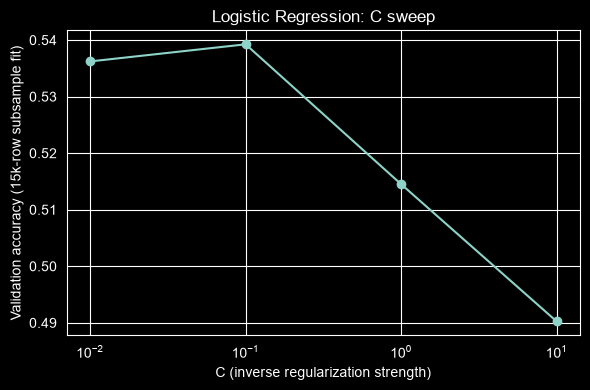


Chosen C = 0.1


In [14]:
# LOGISTIC REGRESSION (SUPERVISED)
# tuning c values
c_values = [0.01, 0.1, 1.0, 10.0]
subsample_idx = np.random.RandomState(1).choice(len(Xtr_s), 15000, replace=False)
c_val_accs = []
for c in c_values:
    lr_tmp = LogisticRegression(C=c, max_iter=300, random_state=42)
    lr_tmp.fit(Xtr_s[subsample_idx], ytr[subsample_idx])
    c_val_accs.append(lr_tmp.score(Xv_s, yv))
    print(f"  C={c:>6}: val acc = {c_val_accs[-1]:.3%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(c_values, c_val_accs, marker='o')
ax.set_xscale('log'); ax.set_xlabel("C (inverse regularization strength)")
ax.set_ylabel("Validation accuracy (15k-row subsample fit)")
ax.set_title("Logistic Regression: C sweep")
plt.tight_layout(); plt.show()

best_c = c_values[int(np.argmax(c_val_accs))]
print(f"\nChosen C = {best_c}")

### Final model and results

50-dim PCA features

In [15]:
t0 = time.time()
lr_model = LogisticRegression(C=best_c, max_iter=300, random_state=42)
lr_model.fit(Xtr_s, ytr)
print(f"fit time: {time.time()-t0:.1f}s")

lr_val_acc = lr_model.score(Xv_s, yv)
print(f"Logistic Regression val accuracy (full 337-dim features): {lr_val_acc:.3%}")

# Dimensionality-reduction comparison: same model on PCA-reduced features
n_components_lr = N_COMPONENTS_COMPARISON
pca_lr = PCA(n_components=n_components_lr, random_state=42).fit(Xtr_s)
Xtr_pca_lr = pca_lr.transform(Xtr_s)
Xv_pca_lr = pca_lr.transform(Xv_s)

lr_pca_model = LogisticRegression(C=best_c, max_iter=300, random_state=42)
lr_pca_model.fit(Xtr_pca_lr, ytr)
lr_pca_val_acc = lr_pca_model.score(Xv_pca_lr, yv)
var_captured = pca_lr.explained_variance_ratio_.sum()
print(f"Logistic Regression val accuracy ({n_components_lr}-dim PCA features, {var_captured:.1%} variance captured): {lr_pca_val_acc:.3%}")
print(f"Accuracy difference from dimensionality reduction: {lr_pca_val_acc - lr_val_acc:+.3%}")

fit time: 9.4s
Logistic Regression val accuracy (full 337-dim features): 60.749%
Logistic Regression val accuracy (50-dim PCA features, 42.5% variance captured): 43.155%
Accuracy difference from dimensionality reduction: -17.595%


Using 50-dim PCA features reduced the accuracy significantly.

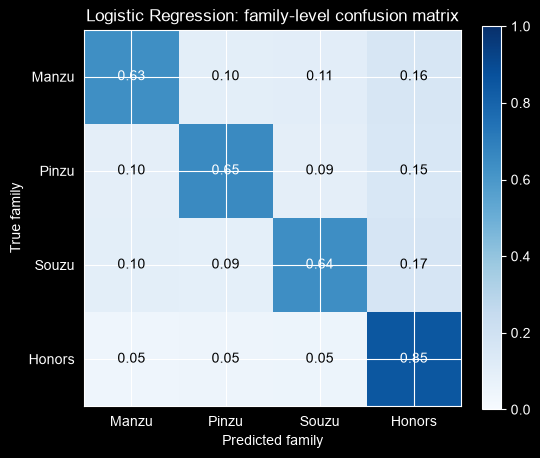

In [8]:
# confusion matrix, aggregated to tile-family level for readability (34x34 is too dense to read directly)
y_pred_lr = lr_model.predict(Xv_s)
fam_true = np.array([tile_family(t) for t in yv])
fam_pred = np.array([tile_family(t) for t in y_pred_lr])
families_order = ["Manzu", "Pinzu", "Souzu", "Honors"]
cm_fam = confusion_matrix(fam_true, fam_pred, labels=families_order, normalize='true')

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_fam, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(families_order)
ax.set_yticks(range(4)); ax.set_yticklabels(families_order)
ax.set_xlabel("Predicted family"); ax.set_ylabel("True family")
ax.set_title("Logistic Regression: family-level confusion matrix")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm_fam[i,j]:.2f}", ha='center', va='center',
                color='white' if cm_fam[i,j] > 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

Correct guesses were high across the boards for predicted family, especially Honor tiles.

### Logistic Regression Model conclusion

Logistic Regression achieves competitive accuracy despite being a simple linear model.

Dimensionality reduction to 50 PCA components (only ~42% of total variance) costs a
large amount of accuracy for this model. This
tells us the useful signal for a linear model is spread fairly evenly across many of
the 337 original dimensions rather than concentrated in a few dominant directions, so
compressing away over half the variance also compresses away real predictive signal
that Logistic Regression was relying on additively.

Logistic Regression is a good baseline fit for this objective on the full feature space. Its main limitations are (1)
a linear decision boundary cannot capture interaction effects between features without
those interactions being explicitly engineered(aka the added features), and (2) it is comparatively fragile to
dimensionality reduction, so it should be used on the full feature set rather than a
PCA-compressed one.

---
# Model 2: Random Forest (Supervised)

**Business objective:** same as Model 1 -- predict the discarded tile type -- using a
different model family (tree ensemble) for comparison.

### Hyperparameters used

`n_estimators` (number of trees) and `max_depth` (tree depth limit) are the primary
hyperparameters tuned here on a coarse level; finer tuning is done in Part 2.

In [16]:
#RANDOM FOREST (SUPERVISED)
rf_configs = [
    {"n_estimators": 50, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 20},
]
rf_results = []
for cfg in rf_configs:
    t0 = time.time()
    rf_tmp = RandomForestClassifier(**cfg, n_jobs=-1, random_state=42)
    rf_tmp.fit(Xtr, ytr)
    acc = rf_tmp.score(Xv, yv)
    fit_time = time.time() - t0
    rf_results.append({**cfg, "val_acc": acc, "fit_time_s": fit_time})
    print(f"  {cfg}: val_acc={acc:.3%}, fit_time={fit_time:.1f}s")

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)
best_cfg = rf_configs[int(rf_results_df["val_acc"].idxmax())]
print(f"\nChosen config: {best_cfg}")

  {'n_estimators': 50, 'max_depth': 10}: val_acc=43.546%, fit_time=2.2s
  {'n_estimators': 100, 'max_depth': 20}: val_acc=50.131%, fit_time=6.6s


,n_estimators,max_depth,val_acc,fit_time_s
0,50,10,0.435464,2.151371
1,100,20,0.501306,6.553180



Chosen config: {'n_estimators': 100, 'max_depth': 20}


### Final model and results

In [10]:
rf_model = RandomForestClassifier(**best_cfg, n_jobs=-1, random_state=42)
rf_model.fit(Xtr, ytr)
rf_val_acc = rf_model.score(Xv, yv)
print(f"Random Forest val accuracy (full 337-dim features): {rf_val_acc:.3%}")

# Dimensionality-reduction comparison: same config on PCA-reduced features
rf_pca_model = RandomForestClassifier(**best_cfg, n_jobs=-1, random_state=42)
rf_pca_model.fit(Xtr_pca_lr, ytr)   # reuse the fixed-size PCA features from Model 1's section
rf_pca_val_acc = rf_pca_model.score(Xv_pca_lr, yv)
print(f"Random Forest val accuracy ({n_components_lr}-dim PCA features): {rf_pca_val_acc:.3%}")
print(f"Accuracy difference from dimensionality reduction: {rf_pca_val_acc - rf_val_acc:+.3%}")

Random Forest val accuracy (full 337-dim features): 50.131%
Random Forest val accuracy (50-dim PCA features): 39.739%
Accuracy difference from dimensionality reduction: -10.392%


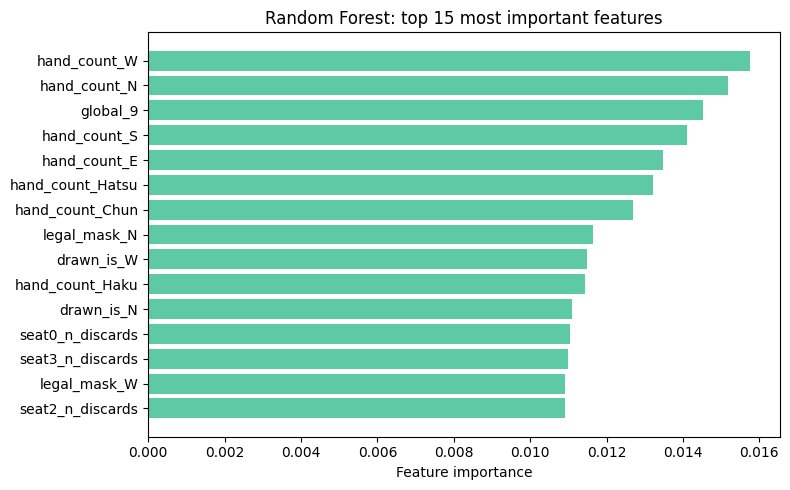

In [10]:
# feature importance (top 15) -- only meaningful on the ORIGINAL feature space, since PCA components aren't interpretable
importances = rf_model.feature_importances_
feature_names = (
    [f"hand_count_{TILE_LABELS[i]}" for i in range(34)] +
    [f"legal_mask_{TILE_LABELS[i]}" for i in range(34)] +
    [f"global_{i}" for i in range(44)] +
    ["shanten_current"] + [f"shanten_after_{TILE_LABELS[i]}" for i in range(34)] +
    [f"drawn_is_{TILE_LABELS[i]}" for i in range(34)] +
    [f"seat{s}_{n}" for s in range(4) for n in
     (["points", "n_discards", "tg_ratio", "riichi"] + [f"meld_{TILE_LABELS[i]}" for i in range(34)] + ["n_melds"])]
)
assert len(feature_names) == X.shape[1]

top_idx = np.argsort(importances)[::-1][:15]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([feature_names[i] for i in top_idx][::-1], importances[top_idx][::-1], color="#5DCAA5")
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest: top 15 most important features")
plt.tight_layout(); plt.show()

### Model 2 conclusion

Random Forest's top features (shown above) are dominated by `shanten_after_*` entries (ends in (M1-M9, P1-P9, S1-S9, E/S/W/N, Haku/Hatsu/Chun))
-- consistent with the earlier finding that tile-efficiency features carry most of the
predictive signal. PCA-reduced features cost Random Forest accuracy too, but
noticeably less than they cost Logistic Regression (roughly a 10pt drop vs. a
17-18pt drop at the same 50-component reduction). Interesting that 50-dims has almost the same accuracy(42.5% vs 39.7%) in both models.

Decent fit but Logistic regression still outperformed by a large margin.

---
# Model 3: K-Means Clustering (Unsupervised)

**Business objective (deliberately different from Models 1-2):** rather than
predicting the exact discard, segment decision-points into a small number of natural
**strategic archetypes** -- e.g. clusters that turn out to represent "deep in a
strong hand, close to tenpai" vs. "early game, far from tenpai" vs. "defensive posture
against an opponent's riichi". This kind of segmentation is useful for downstream
analytics/coaching tools (e.g. "show me all decisions like this one") rather than for
directly automating a discard choice.

### Dimensionality reduction (used here as a modeling choice, not just diagnostics)

Distance-based clustering algorithms like K-Means degrade in high-dimensional spaces
(the curse of dimensionality flattens pairwise distances). We cluster in a
reduced-dimensional PCA space instead of the raw 337-dim space, and use inertia
(elbow method) and silhouette score across a range of `k` as supporting data to choose
both the number of PCA components and the number of clusters.

Variance captured by 20 components: 25.6%
  k=2: inertia=4680054, silhouette=0.204
  k=3: inertia=4204430, silhouette=0.165
  k=4: inertia=3936132, silhouette=0.121
  k=5: inertia=3770025, silhouette=0.119
  k=6: inertia=3639054, silhouette=0.092
  k=7: inertia=3567142, silhouette=0.093
  k=8: inertia=3507405, silhouette=0.075
  k=9: inertia=3455658, silhouette=0.091
  k=10: inertia=3411036, silhouette=0.070


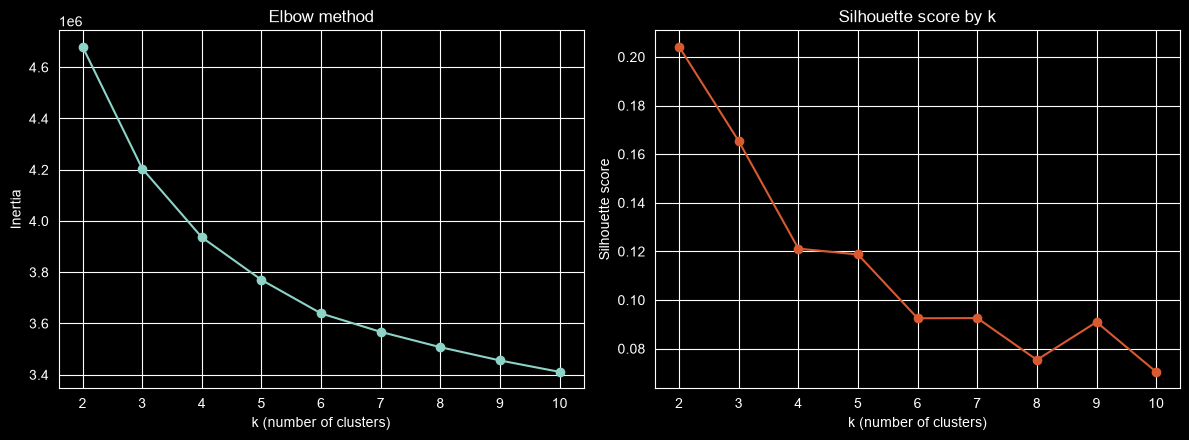

In [19]:
#MODEL 3: K-MEANS CLUSTERING (UNSUPERVISED)
n_components_km = 20  # captures ~25-30% of variance, enough structure for clustering without high-dim noise
pca_km = PCA(n_components=n_components_km, random_state=42).fit(Xtr_s)
Xtr_km = pca_km.transform(Xtr_s)
Xv_km = pca_km.transform(Xv_s)
print(f"Variance captured by {n_components_km} components: {pca_km.explained_variance_ratio_.sum():.1%}")

k_range = range(2, 11)
inertias, silhouettes = [], []
sil_sample_idx = np.random.RandomState(2).choice(len(Xtr_km), 5000, replace=False)
for k in k_range:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_tmp = km_tmp.fit_predict(Xtr_km)
    inertias.append(km_tmp.inertia_)
    silhouettes.append(silhouette_score(Xtr_km[sil_sample_idx], labels_tmp[sil_sample_idx]))
    print(f"  k={k}: inertia={km_tmp.inertia_:.0f}, silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel("k (number of clusters)"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[1].plot(list(k_range), silhouettes, marker='o', color="#D85A30")
axes[1].set_xlabel("k (number of clusters)"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")
plt.tight_layout(); plt.show()

In [20]:
chosen_k = 5  # elbow bend + reasonably high silhouette relative to neighbors
km_model = KMeans(n_clusters=chosen_k, n_init=10, random_state=42)
train_clusters = km_model.fit_predict(Xtr_km)
val_clusters = km_model.predict(Xv_km)

print(f"Chosen k = {chosen_k}")
print(f"Cluster sizes (train): {np.bincount(train_clusters)}")

# recover current_shanten and remain_tiles from the original unscaled feature vector for interpretability
current_shanten_col = 34 + 34 + 44   # index of the current_shanten scalar (see feature layout)
remain_tiles_col = 34 + 34 + 3 + 4   # honba(1)+riichi(1)+remain(1) block -- remain_tiles is the 3rd of those, adjust below
# global_feats layout: round_wind(3) + position(4) + [honba, riichi, remain_tiles](3) + dora(34)
remain_tiles_idx = 34 + 34 + 3 + 4 + 2
current_shanten_idx = 34 + 34 + 44  # start of shanten block

profile_rows = []
for c in range(chosen_k):
    mask_c = train_clusters == c
    profile_rows.append({
        "cluster": c,
        "n_rows": mask_c.sum(),
        "avg_current_shanten": Xtr[mask_c, current_shanten_idx].mean() * 8,  # undo the /8.0 normalization
        "avg_remain_tiles": Xtr[mask_c, remain_tiles_idx].mean() * 70,        # undo the /70.0 normalization
        "riichi_rate_seat0": Xtr[mask_c, 34+34+44+35+34+3].mean(),           # seat0's riichi flag within its block
    })
profile_df = pd.DataFrame(profile_rows)
display(profile_df)

Chosen k = 5
Cluster sizes (train): [ 8771 16738 26606 12506  5445]


,cluster,n_rows,avg_current_shanten,avg_remain_tiles,riichi_rate_seat0
0,0,8771,2.343746,30.520466,0.025653
1,1,16738,3.280261,60.112377,0.000000
2,2,26606,1.566865,51.146847,0.000038
3,3,12506,0.281465,27.313211,0.521430
4,4,5445,4.583838,35.366024,0.000551


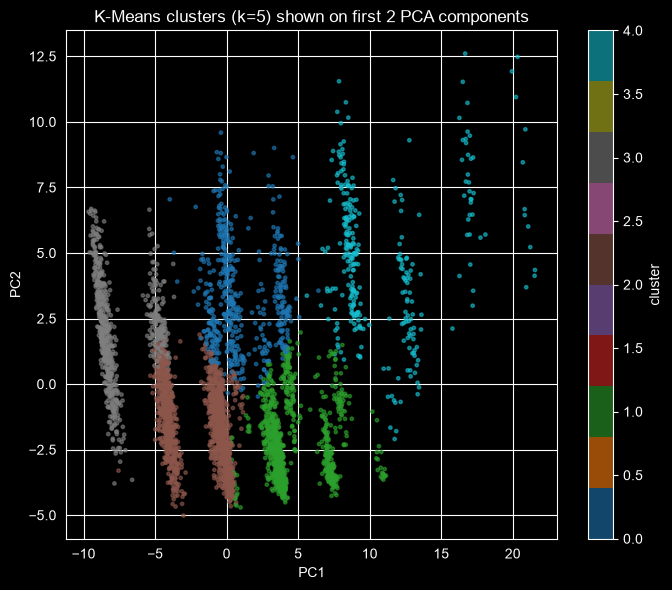

In [21]:
# 2D visualization of clusters (reuse the earlier 2D PCA projection for a consistent view)
Xtr_2d_km = pca_2d.transform(Xtr_s[sample_idx])
cluster_sample = train_clusters[sample_idx]

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(Xtr_2d_km[:, 0], Xtr_2d_km[:, 1], c=cluster_sample, cmap='tab10', s=6, alpha=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means clusters (k={chosen_k}) shown on first 2 PCA components")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout(); plt.show()

### Model 3 conclusion

The cluster profile table shows clusters separating primarily along hand progress
(average shanten) and game-stage (average tiles remaining)  even though the
model was never told about shanten or turn number as a target. Silhouette scores in
the 0.1-0.2 range indicate the clusters are real but not sharply separated -- expected
for continuous game-state data without natural hard boundaries.

Looking at the dataset, there's no way to distinguish between players in different games. In a game, I could identify a player by their seat and round wind. Going to stop pursing this direction.

---
# Overall summary

| Model | Type | Objective | Key result                                                                                |
|---|---|---|-------------------------------------------------------------------------------------------|
| Logistic Regression | Supervised | Predict discard | Best accuracy of the three; large accuracy cost from PCA reduction                        |
| Random Forest | Supervised | Predict discard | Underperforms LR at this tuning depth; more robust to PCA reduction than LR               |
| K-Means | Unsupervised | Segment into strategic archetypes | Clusters track shanten/game-stage meaningfully; silhouette is modest. Unable to continue. |
